# Tuning des paramètres — Recuit Simulé VRPTW
## Analyse par taille de problème : n = 10, 20, 50, 100, 200

> **Objectif** : Trouver les paramètres optimaux du recuit simulé pour chaque taille de problème.
>
> | Paramètre | Famille | Rôle |
> |---|---|---|
> | `T0` — température initiale | **Diversification** | Haute T0 → accepte plus de mauvaises solutions → explore largement |
> | `alpha` — taux de refroidissement | **Intensification** | Alpha proche de 1 → refroidissement lent → exploite davantage |
> | `n_iter` — nombre d'itérations | **Budget** | Plus d'itérations = plus de temps pour converger |
>
> **Comparaison avec le génétique** : le recuit est fondamentalement différent — il maintient **une seule solution** et explore via des voisinages locaux (2-opt, or-opt). Moins de diversité génétique, mais une exploration locale bien plus fine à chaque itération.
>
> **Temps estimé** : rapide (~5 min tout inclus) — le recuit est O(n_iter × n) par run, beaucoup plus léger que le génétique.

---

## Table des matières
1. [Setup & Baseline](#1)
2. [Effet de `n_iter` — Budget de calcul](#2)
3. [Effet de `T0` — Diversification](#3)
4. [Effet de `alpha` — Intensification](#4)
5. [Grid search T0 × alpha par taille](#5)
6. [Courbes de convergence comparées](#6)
7. [Bilan & Configuration recommandée par taille](#7)

---
<a id='1'></a>
## 1. Setup & Baseline

In [1]:
import sys, os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Chemins ───────────────────────────────────────────────────────
# Notebook : .../Projet/Phase 3/Algo_Recuit/
SA_DIR    = os.path.abspath('.')
BENCH_DIR = os.path.abspath(os.path.join('..', '..', 'Benchmark'))

if SA_DIR not in sys.path:
    sys.path.insert(0, SA_DIR)

import importlib, simulated_annealing as sa_module
importlib.reload(sa_module)
from simulated_annealing import recuit_simule, cout_solution

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# ── Tailles et seeds ──────────────────────────────────────────────
# Le recuit est bien plus rapide que le GA → on peut se permettre plus de seeds
TAILLES = [10, 20, 50, 100, 200]

N_SEEDS_PAR_TAILLE = {
    10:  20,
    20:  15,
    50:  10,
    100:  8,
    200:  5,
}

# ── Chargement des instances ──────────────────────────────────────
with open(os.path.join(BENCH_DIR, 'results', 'oracle_results.json')) as f:
    oracle_data = json.load(f)

def load_instance(n, seed):
    path = os.path.join(BENCH_DIR, 'instances', f'n{n}', f'instance_n{n}_seed{seed}.json')
    with open(path) as f:
        d = json.load(f)
    return {
        'n': d['n'], 'n_vehicles': d['n_vehicles'],
        'coords':       np.array(d['coords']),
        'dist':         np.array(d['dist']),
        'durees':       np.array(d['durees']),
        'demands':      np.array(d['demands']),
        'capacity':     d['capacity'],
        'time_windows': np.array(d['time_windows']),
        'service_times':np.array(d['service_times']),
        'horizon':      d['horizon'],
    }

ALL_INSTANCES = {}
ALL_ORACLES   = {}
for n in TAILLES:
    ns = N_SEEDS_PAR_TAILLE[n]
    ALL_INSTANCES[n] = {s: load_instance(n, s) for s in range(ns)}
    ALL_ORACLES[n]   = {s: oracle_data[f'n{n}_seed{s}']['cost'] for s in range(ns)}

print("Instances chargées :")
for n in TAILLES:
    ns = N_SEEDS_PAR_TAILLE[n]
    print(f"  n={n:4d} : {ns} seeds | oracle moy = {np.mean(list(ALL_ORACLES[n].values())):.1f}")

# ── Fonction utilitaire centrale ──────────────────────────────────
def run_config(n, T0, alpha, n_iter):
    """
    Lance le recuit sur les N_SEEDS_PAR_TAILLE[n] instances de taille n.
    Retourne gap_moy, gap_std, gap_min, gap_max, t_moy.
    """
    ns = N_SEEDS_PAR_TAILLE[n]
    gaps, times = [], []
    for s in range(ns):
        t0 = time.time()
        sol, cout, hist = recuit_simule(
            ALL_INSTANCES[n][s], T0=T0, alpha=alpha, n_iter=n_iter, seed=s)
        # recuit_simule retourne le cout pénalisé — on recalcule le cout réel
        cout_reel = cout_solution(sol, ALL_INSTANCES[n][s])
        gap = (cout_reel - ALL_ORACLES[n][s]) / ALL_ORACLES[n][s] * 100
        gaps.append(gap)
        times.append(time.time() - t0)
    return {
        'gap_moy': np.mean(gaps), 'gap_med': np.median(gaps),
        'gap_std': np.std(gaps),  'gap_min': np.min(gaps),
        'gap_max': np.max(gaps),  't_moy':   np.mean(times),
        'gaps': gaps,
    }

# ── Baselines par taille ──────────────────────────────────────────
# Paramètres par défaut de recuit_simule : T0=1000, alpha=0.995, n_iter=10000
# On adapte n_iter à la taille pour un temps similaire au génétique
BASELINES = {
    10:  dict(T0=1000.0, alpha=0.995, n_iter=5000),
    20:  dict(T0=1000.0, alpha=0.995, n_iter=10000),
    50:  dict(T0=1000.0, alpha=0.995, n_iter=20000),
    100: dict(T0=1000.0, alpha=0.995, n_iter=30000),
    200: dict(T0=1000.0, alpha=0.995, n_iter=50000),
}

print("\nBaseline par taille :")
BASE_RESULTS = {}
for n in TAILLES:
    r = run_config(n, **BASELINES[n])
    BASE_RESULTS[n] = r
    print(f"  n={n:4d} : gap_moy={r['gap_moy']:+.2f}%  "
          f"gap_std={r['gap_std']:.2f}%  t={r['t_moy']:.3f}s")

colors_n = {10:'#4C9BE8', 20:'#F4845F', 50:'#56C596', 100:'#9B59B6', 200:'#E74C3C'}

Instances chargées :
  n=  10 : 20 seeds | oracle moy = 401.6
  n=  20 : 15 seeds | oracle moy = 563.7
  n=  50 : 10 seeds | oracle moy = 889.9
  n= 100 : 8 seeds | oracle moy = 1443.8
  n= 200 : 5 seeds | oracle moy = 2320.0

Baseline par taille :
  n=  10 : gap_moy=+3.31%  gap_std=3.50%  t=0.516s
  n=  20 : gap_moy=+14.63%  gap_std=8.71%  t=1.419s
  n=  50 : gap_moy=+29.73%  gap_std=5.75%  t=5.586s
  n= 100 : gap_moy=+42.06%  gap_std=7.50%  t=15.429s
  n= 200 : gap_moy=+68.70%  gap_std=9.72%  t=48.910s


---
<a id='2'></a>
## 2. Effet de `n_iter` — Budget de calcul

`n_iter` contrôle le nombre total d'itérations. C'est le levier le plus direct : plus on cherche, mieux on trouve.

**Attendu :** amélioration rapide puis plateau quand l'algo a convergé. Le plateau arrive plus tard pour les grandes instances.


n=10 (T0=1000.0, alpha=0.995) :
  n_iter=   1000  gap= +8.41%  ±6.42%  t=0.106s
  n_iter=   3000  gap= +3.31%  ±3.50%  t=0.312s
  n_iter=   5000  gap= +3.31%  ±3.50%  t=0.509s
  n_iter=  10000  gap= +3.31%  ±3.50%  t=0.993s
  n_iter=  20000  gap= +3.31%  ±3.50%  t=1.988s

n=20 (T0=1000.0, alpha=0.995) :
  n_iter=   2000  gap=+20.98%  ±12.80%  t=0.292s
  n_iter=   5000  gap=+14.98%  ±9.32%  t=0.719s
  n_iter=  10000  gap=+14.63%  ±8.71%  t=1.425s
  n_iter=  20000  gap=+14.63%  ±8.71%  t=2.887s
  n_iter=  50000  gap=+14.63%  ±8.71%  t=7.112s

n=50 (T0=1000.0, alpha=0.995) :
  n_iter=   5000  gap=+53.21%  ±16.03%  t=1.444s
  n_iter=  10000  gap=+39.14%  ±13.17%  t=2.922s
  n_iter=  20000  gap=+29.73%  ±5.75%  t=5.597s
  n_iter=  50000  gap=+25.65%  ±5.76%  t=14.122s
  n_iter= 100000  gap=+25.65%  ±5.76%  t=27.956s

n=100 (T0=1000.0, alpha=0.995) :
  n_iter=  10000  gap=+84.37%  ±10.03%  t=5.295s
  n_iter=  20000  gap=+53.72%  ±9.49%  t=10.629s
  n_iter=  30000  gap=+42.06%  ±7.50%  t=17.

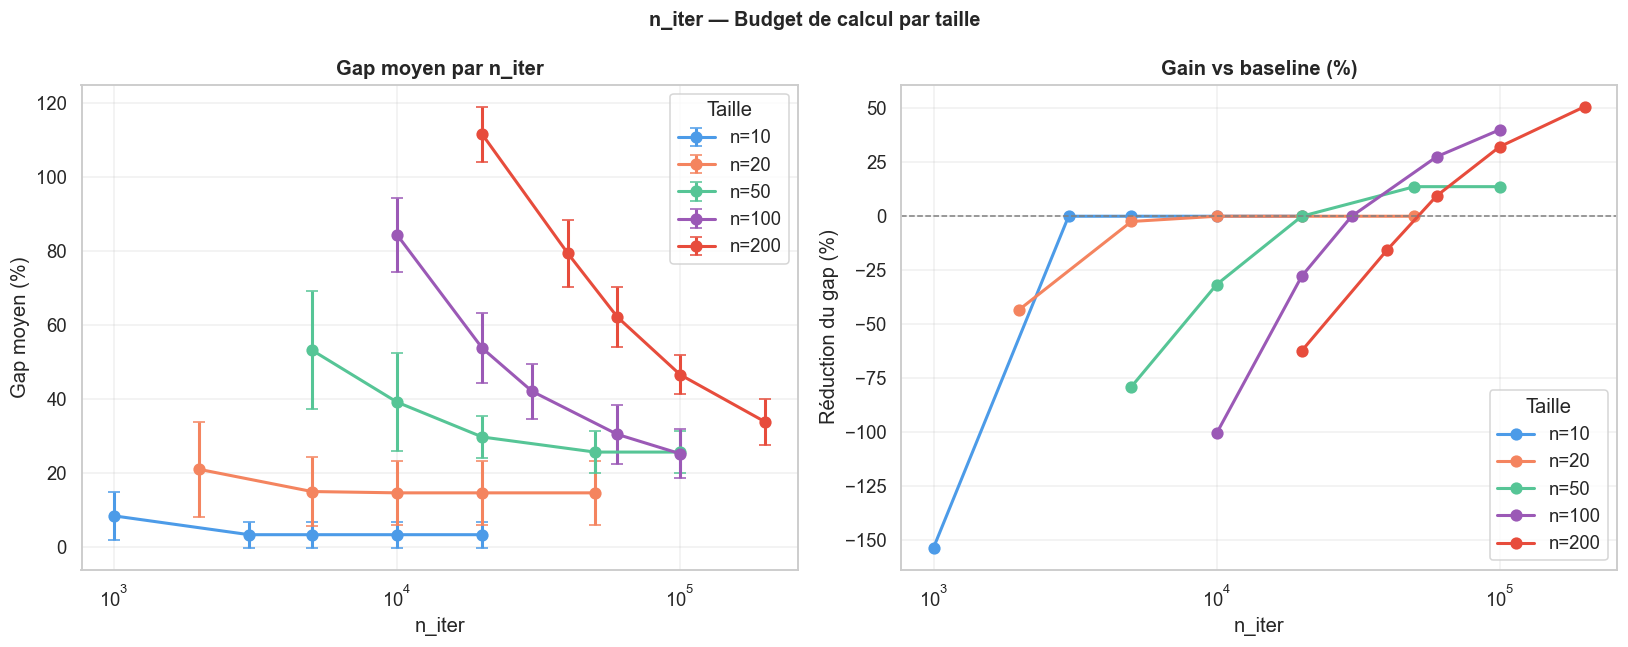


n_iter optimal par taille :
  n=  10 : iter_opt=   3000  gap=+3.31%  (baseline +3.31%  gain=+0.00pts)
  n=  20 : iter_opt=  10000  gap=+14.63%  (baseline +14.63%  gain=+0.00pts)
  n=  50 : iter_opt=  50000  gap=+25.65%  (baseline +29.73%  gain=+4.07pts)
  n= 100 : iter_opt= 100000  gap=+25.21%  (baseline +42.06%  gain=+16.85pts)
  n= 200 : iter_opt= 200000  gap=+33.78%  (baseline +68.70%  gain=+34.92pts)


In [2]:
ITER_PAR_TAILLE = {
    10:  [1000, 3000, 5000, 10000, 20000],
    20:  [2000, 5000, 10000, 20000, 50000],
    50:  [5000, 10000, 20000, 50000, 100000],
    100: [10000, 20000, 30000, 60000, 100000],
    200: [20000, 40000, 60000, 100000, 200000],
}

results_iter = {n: [] for n in TAILLES}

for n in TAILLES:
    T0    = BASELINES[n]['T0']
    alpha = BASELINES[n]['alpha']
    print(f"\nn={n} (T0={T0}, alpha={alpha}) :")
    for n_iter in ITER_PAR_TAILLE[n]:
        r = run_config(n, T0=T0, alpha=alpha, n_iter=n_iter)
        r['n_iter'] = n_iter
        results_iter[n].append(r)
        print(f"  n_iter={n_iter:7d}  gap={r['gap_moy']:+6.2f}%  ±{r['gap_std']:.2f}%  t={r['t_moy']:.3f}s")

# ── Visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for n in TAILLES:
    iters   = [r['n_iter']  for r in results_iter[n]]
    gap_moy = [r['gap_moy'] for r in results_iter[n]]
    gap_std = [r['gap_std'] for r in results_iter[n]]
    base    = BASE_RESULTS[n]['gap_moy']
    c = colors_n[n]

    axes[0].errorbar(iters, gap_moy, yerr=gap_std, fmt='o-',
                     color=c, linewidth=2, capsize=4, markersize=7, label=f'n={n}')

    gain = [(base - g) / abs(base) * 100 if base != 0 else 0 for g in gap_moy]
    axes[1].plot(iters, gain, 'o-', color=c, linewidth=2, markersize=7, label=f'n={n}')

axes[0].set_title('Gap moyen par n_iter', fontweight='bold')
axes[0].set_xlabel('n_iter')
axes[0].set_ylabel('Gap moyen (%)')
axes[0].set_xscale('log')
axes[0].legend(title='Taille')

axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Gain vs baseline (%)', fontweight='bold')
axes[1].set_xlabel('n_iter')
axes[1].set_ylabel('Réduction du gap (%)')
axes[1].set_xscale('log')
axes[1].legend(title='Taille')

for ax in axes:
    ax.grid(alpha=0.3)

plt.suptitle('n_iter — Budget de calcul par taille', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nn_iter optimal par taille :")
for n in TAILLES:
    best = min(results_iter[n], key=lambda r: r['gap_moy'])
    base = BASE_RESULTS[n]['gap_moy']
    print(f"  n={n:4d} : iter_opt={best['n_iter']:7d}  "
          f"gap={best['gap_moy']:+.2f}%  (baseline {base:+.2f}%  gain={base-best['gap_moy']:+.2f}pts)")

---
<a id='3'></a>
## 3. Effet de `T0` — Diversification

`T0` est la température initiale. Une T0 élevée signifie qu'au départ l'algo accepte presque n'importe quelle solution (même très mauvaise) avec une probabilité proche de 1 → **exploration large**.

- **T0 trop faible** → l'algo commence déjà en mode exploitation, risque fort de rester dans le premier optimum local trouvé
- **T0 trop élevée** → trop de temps passé à accepter des mauvaises solutions, l'algo converge lentement

**Clé** : T0 doit être calibré pour que la probabilité d'accepter une solution *légèrement* pire (~5-10% de dégradation) soit ~80% au début.


n=10 (alpha=0.995, n_iter=5000) :
  T0=     50  gap= +3.59%  ±4.83%
  T0=    200  gap= +5.86%  ±4.58%
  T0=    500  gap= +2.29%  ±3.21%
  T0=   1000  gap= +3.31%  ±3.50%
  T0=   2000  gap= +3.47%  ±3.89%
  T0=   5000  gap= +4.63%  ±4.87%
  T0=  10000  gap= +2.93%  ±3.47%

n=20 (alpha=0.995, n_iter=10000) :
  T0=     50  gap=+15.59%  ±9.43%
  T0=    200  gap=+15.65%  ±11.47%
  T0=    500  gap=+13.67%  ±7.94%
  T0=   1000  gap=+14.63%  ±8.71%
  T0=   2000  gap=+16.31%  ±9.64%
  T0=   5000  gap=+13.70%  ±11.29%
  T0=  10000  gap=+11.39%  ±6.57%

n=50 (alpha=0.995, n_iter=20000) :
  T0=     50  gap=+32.66%  ±6.97%
  T0=    200  gap=+32.08%  ±8.92%
  T0=    500  gap=+32.36%  ±7.58%
  T0=   1000  gap=+29.73%  ±5.75%
  T0=   2000  gap=+27.07%  ±10.14%
  T0=   5000  gap=+32.61%  ±10.78%
  T0=  10000  gap=+28.04%  ±9.78%

n=100 (alpha=0.995, n_iter=30000) :
  T0=     50  gap=+42.06%  ±9.81%
  T0=    200  gap=+42.77%  ±5.09%
  T0=    500  gap=+43.40%  ±6.96%
  T0=   1000  gap=+42.06%  ±7.50%
  

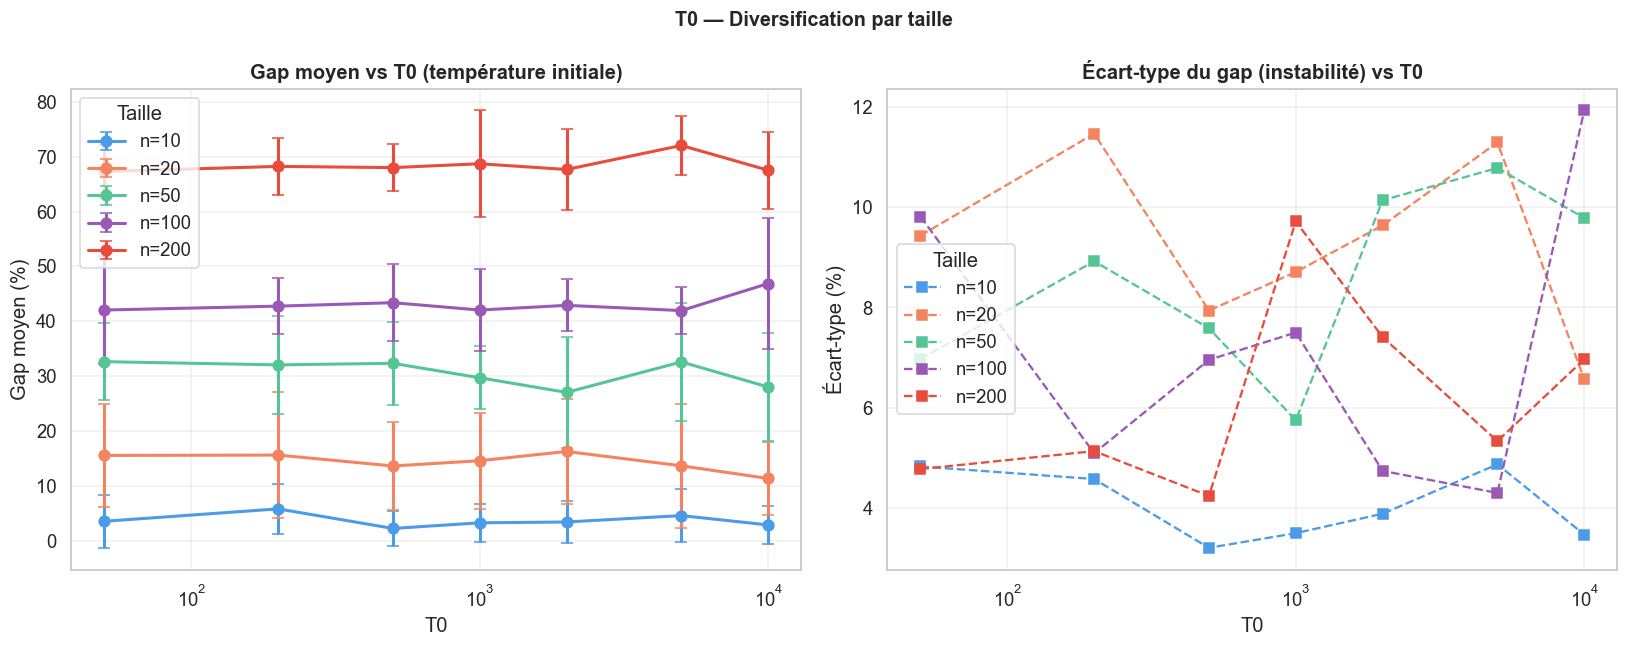

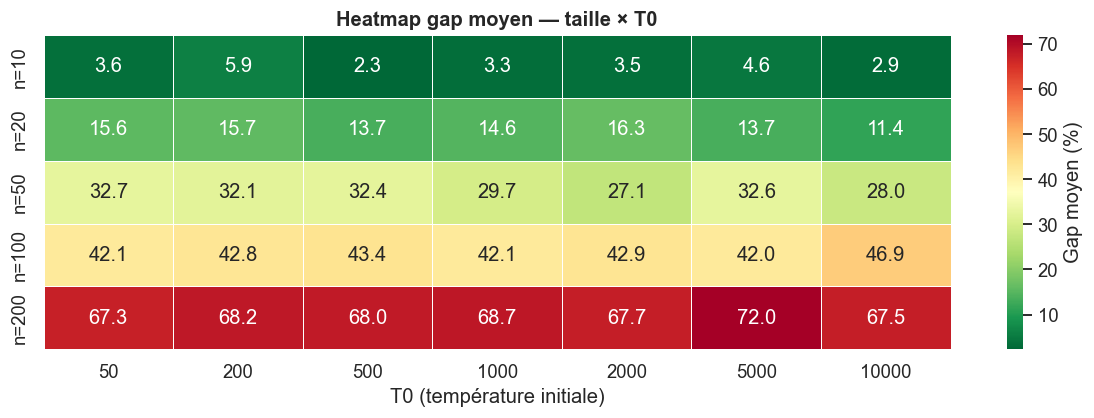


T0 optimal par taille :
  n=  10 : T0_opt=    500  gap=+2.29%
  n=  20 : T0_opt=  10000  gap=+11.39%
  n=  50 : T0_opt=   2000  gap=+27.07%
  n= 100 : T0_opt=   5000  gap=+41.96%
  n= 200 : T0_opt=     50  gap=+67.29%


In [3]:
T0_VALS = [50, 200, 500, 1000, 2000, 5000, 10000]

results_T0 = {n: [] for n in TAILLES}

for n in TAILLES:
    alpha  = BASELINES[n]['alpha']
    n_iter = BASELINES[n]['n_iter']
    print(f"\nn={n} (alpha={alpha}, n_iter={n_iter}) :")
    for T0 in T0_VALS:
        r = run_config(n, T0=T0, alpha=alpha, n_iter=n_iter)
        r['T0'] = T0
        results_T0[n].append(r)
        print(f"  T0={T0:7.0f}  gap={r['gap_moy']:+6.2f}%  ±{r['gap_std']:.2f}%")

# ── Visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for n in TAILLES:
    T0s     = [r['T0']     for r in results_T0[n]]
    gap_moy = [r['gap_moy'] for r in results_T0[n]]
    gap_std = [r['gap_std'] for r in results_T0[n]]
    c = colors_n[n]
    axes[0].errorbar(T0s, gap_moy, yerr=gap_std, fmt='o-',
                     color=c, linewidth=2, capsize=4, markersize=7, label=f'n={n}')
    axes[1].plot(T0s, gap_std, 's--', color=c, linewidth=1.5, markersize=6, label=f'n={n}')

axes[0].set_title('Gap moyen vs T0 (température initiale)', fontweight='bold')
axes[0].set_xlabel('T0')
axes[0].set_ylabel('Gap moyen (%)')
axes[0].set_xscale('log')
axes[0].legend(title='Taille')

axes[1].set_title('Écart-type du gap (instabilité) vs T0', fontweight='bold')
axes[1].set_xlabel('T0')
axes[1].set_ylabel('Écart-type (%)')
axes[1].set_xscale('log')
axes[1].legend(title='Taille')

for ax in axes:
    ax.grid(alpha=0.3)

plt.suptitle('T0 — Diversification par taille', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Heatmap taille × T0
mat = np.array([[r['gap_moy'] for r in results_T0[n]] for n in TAILLES])
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(mat,
            xticklabels=[str(int(t)) for t in T0_VALS],
            yticklabels=[f"n={n}" for n in TAILLES],
            annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Gap moyen (%)'},
            ax=ax)
ax.set_title('Heatmap gap moyen — taille × T0', fontweight='bold')
ax.set_xlabel('T0 (température initiale)')
plt.tight_layout()
plt.show()

print("\nT0 optimal par taille :")
for n in TAILLES:
    best = min(results_T0[n], key=lambda r: r['gap_moy'])
    print(f"  n={n:4d} : T0_opt={best['T0']:7.0f}  gap={best['gap_moy']:+.2f}%")

---
<a id='4'></a>
## 4. Effet de `alpha` — Intensification (vitesse de refroidissement)

`alpha` contrôle la vitesse de refroidissement : `T_{t+1} = alpha × T_t`.

- **alpha proche de 1** (ex: 0.999) → refroidissement très lent → l'algo passe beaucoup de temps à haute température → **plus de diversification**
- **alpha faible** (ex: 0.90) → refroidissement rapide → exploitation rapide → **plus d'intensification**, mais convergence prématurée si T0 était haute

**Tension** : alpha élevé + n_iter fixe → la température ne descend jamais assez → l'algo reste toujours en mode "exploration" et ne converge pas.


n=10 (T0=1000.0, n_iter=5000) :
  alpha=0.900  T_fin=1.63e-226  gap= +7.40%  ±5.84%
  alpha=0.950  T_fin=4.15e-109  gap= +5.35%  ±6.51%
  alpha=0.970  T_fin=7.22e-64  gap= +6.40%  ±6.28%
  alpha=0.990  T_fin=1.50e-19  gap= +5.55%  ±6.29%
  alpha=0.995  T_fin=1.30e-08  gap= +3.31%  ±3.50%
  alpha=0.999  T_fin=6.72e+00  gap= +2.21%  ±2.40%

n=20 (T0=1000.0, n_iter=10000) :
  alpha=0.900  T_fin=0.00e+00  gap=+15.98%  ±10.89%
  alpha=0.950  T_fin=1.72e-220  gap=+14.52%  ±7.34%
  alpha=0.970  T_fin=5.22e-130  gap=+13.27%  ±7.50%
  alpha=0.990  T_fin=2.25e-41  gap=+15.05%  ±7.09%
  alpha=0.995  T_fin=1.70e-19  gap=+14.63%  ±8.71%
  alpha=0.999  T_fin=4.52e-02  gap=+10.68%  ±7.05%

n=50 (T0=1000.0, n_iter=20000) :
  alpha=0.900  T_fin=0.00e+00  gap=+34.19%  ±8.56%
  alpha=0.950  T_fin=0.00e+00  gap=+33.37%  ±8.59%
  alpha=0.970  T_fin=2.72e-262  gap=+32.28%  ±7.37%
  alpha=0.990  T_fin=5.06e-85  gap=+31.87%  ±6.71%
  alpha=0.995  T_fin=2.89e-41  gap=+29.73%  ±5.75%
  alpha=0.999  T_fin=2.04e

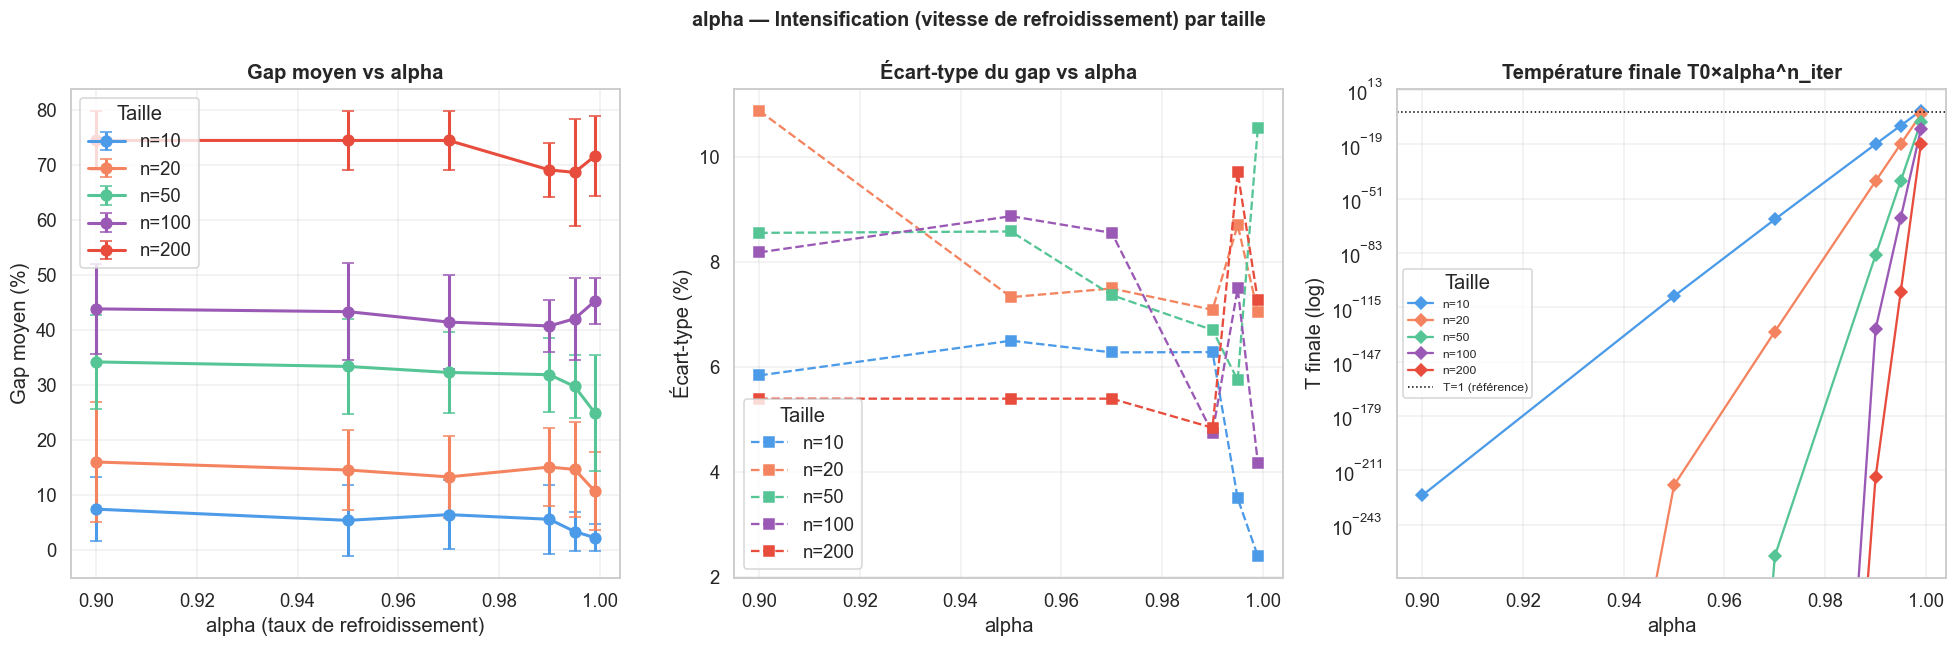

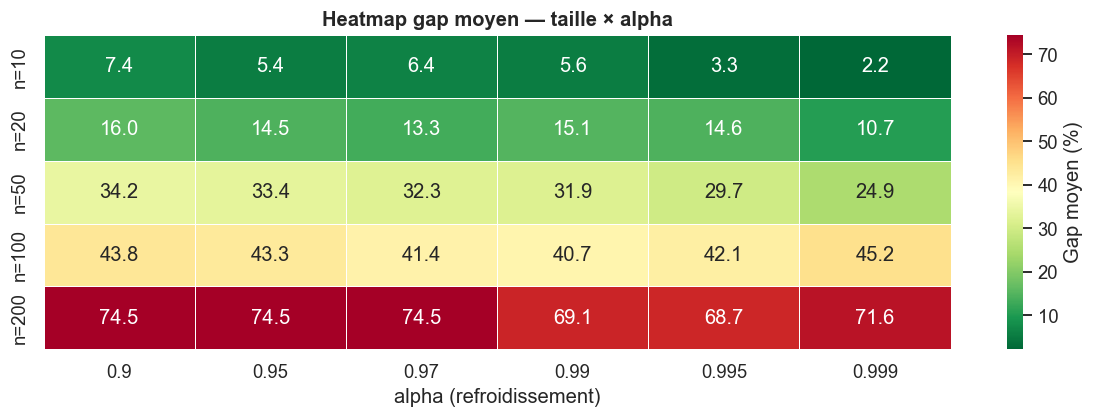


alpha optimal par taille :
  n=  10 : alpha_opt=0.999  T_fin=6.72e+00  gap=+2.21%
  n=  20 : alpha_opt=0.999  T_fin=4.52e-02  gap=+10.68%
  n=  50 : alpha_opt=0.999  T_fin=2.04e-06  gap=+24.94%
  n= 100 : alpha_opt=0.990  T_fin=1.14e-128  gap=+40.74%
  n= 200 : alpha_opt=0.995  T_fin=1.43e-106  gap=+68.70%


In [4]:
ALPHA_VALS = [0.90, 0.95, 0.97, 0.99, 0.995, 0.999]

results_alpha = {n: [] for n in TAILLES}

for n in TAILLES:
    T0     = BASELINES[n]['T0']
    n_iter = BASELINES[n]['n_iter']
    print(f"\nn={n} (T0={T0}, n_iter={n_iter}) :")
    for alpha in ALPHA_VALS:
        r = run_config(n, T0=T0, alpha=alpha, n_iter=n_iter)
        r['alpha'] = alpha
        # Température finale = T0 × alpha^n_iter
        T_fin = T0 * (alpha ** n_iter)
        r['T_fin'] = T_fin
        results_alpha[n].append(r)
        print(f"  alpha={alpha:.3f}  T_fin={T_fin:.2e}  gap={r['gap_moy']:+6.2f}%  ±{r['gap_std']:.2f}%")

# ── Visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for n in TAILLES:
    alphas  = [r['alpha']   for r in results_alpha[n]]
    gap_moy = [r['gap_moy'] for r in results_alpha[n]]
    gap_std = [r['gap_std'] for r in results_alpha[n]]
    T_fins  = [r['T_fin']   for r in results_alpha[n]]
    c = colors_n[n]

    axes[0].errorbar(alphas, gap_moy, yerr=gap_std, fmt='o-',
                     color=c, linewidth=2, capsize=4, markersize=7, label=f'n={n}')
    axes[1].plot(alphas, gap_std, 's--', color=c, linewidth=1.5, markersize=6, label=f'n={n}')
    axes[2].plot(alphas, T_fins, 'D-', color=c, linewidth=1.5, markersize=6, label=f'n={n}')

axes[0].set_title('Gap moyen vs alpha', fontweight='bold')
axes[0].set_xlabel('alpha (taux de refroidissement)')
axes[0].set_ylabel('Gap moyen (%)')
axes[0].legend(title='Taille')

axes[1].set_title('Écart-type du gap vs alpha', fontweight='bold')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('Écart-type (%)')
axes[1].legend(title='Taille')

axes[2].set_title('Température finale T0×alpha^n_iter', fontweight='bold')
axes[2].set_xlabel('alpha')
axes[2].set_ylabel('T finale (log)')
axes[2].set_yscale('log')
axes[2].axhline(1, color='black', linestyle=':', linewidth=1, label='T=1 (référence)')
axes[2].legend(title='Taille', fontsize=8)

for ax in axes:
    ax.grid(alpha=0.3)

plt.suptitle('alpha — Intensification (vitesse de refroidissement) par taille',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Heatmap taille × alpha
mat = np.array([[r['gap_moy'] for r in results_alpha[n]] for n in TAILLES])
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(mat,
            xticklabels=[str(a) for a in ALPHA_VALS],
            yticklabels=[f"n={n}" for n in TAILLES],
            annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Gap moyen (%)'},
            ax=ax)
ax.set_title('Heatmap gap moyen — taille × alpha', fontweight='bold')
ax.set_xlabel('alpha (refroidissement)')
plt.tight_layout()
plt.show()

print("\nalpha optimal par taille :")
for n in TAILLES:
    best = min(results_alpha[n], key=lambda r: r['gap_moy'])
    T_fin = BASELINES[n]['T0'] * (best['alpha'] ** BASELINES[n]['n_iter'])
    print(f"  n={n:4d} : alpha_opt={best['alpha']:.3f}  T_fin={T_fin:.2e}  gap={best['gap_moy']:+.2f}%")

---
<a id='5'></a>
## 5. Grid search T0 × alpha par taille

On fait varier simultanément `T0` (diversification) et `alpha` (intensification).
La heatmap révèle l'**interaction** entre les deux : une T0 élevée avec un alpha faible peut être catastrophique (l'algo refroidit trop vite après une exploration initiale trop chaotique).

In [ ]:
GRID_T0    = [200, 1000, 5000, 10000]
GRID_ALPHA = [0.95, 0.99, 0.995, 0.999]

GRID_RESULTS = {}

for n in TAILLES:
    n_iter = BASELINES[n]['n_iter']
    total  = len(GRID_T0) * len(GRID_ALPHA)
    print(f"\nn={n} — grid {len(GRID_T0)}×{len(GRID_ALPHA)} = {total} configs (n_iter={n_iter}) :")
    mat  = np.zeros((len(GRID_T0), len(GRID_ALPHA)))
    done = 0
    for i, T0 in enumerate(GRID_T0):
        for j, alpha in enumerate(GRID_ALPHA):
            r = run_config(n, T0=T0, alpha=alpha, n_iter=n_iter)
            mat[i, j] = r['gap_moy']
            done += 1
            print(f"  [{done:2d}/{total}] T0={T0:6.0f} alpha={alpha:.3f}  gap={r['gap_moy']:+.2f}%")
    GRID_RESULTS[n] = {'mat': mat}

# ── Heatmaps ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(TAILLES), figsize=(5 * len(TAILLES), 5))

BEST_COMBOS = {}
for ax, n in zip(axes, TAILLES):
    mat = GRID_RESULTS[n]['mat']
    sns.heatmap(mat,
                xticklabels=[str(a) for a in GRID_ALPHA],
                yticklabels=[str(int(t)) for t in GRID_T0],
                annot=True, fmt='.1f', cmap='RdYlGn_r',
                linewidths=0.5, cbar_kws={'label': 'Gap (%)'},
                ax=ax)
    idx = np.unravel_index(np.argmin(mat), mat.shape)
    ax.add_patch(plt.Rectangle((idx[1], idx[0]), 1, 1,
                                fill=False, edgecolor='blue', linewidth=3))
    ax.set_title(f'n={n}', fontweight='bold')
    ax.set_xlabel('alpha →\n(intensification)')
    ax.set_ylabel('T0\n(diversification) ↑')
    BEST_COMBOS[n] = {
        'T0': GRID_T0[idx[0]], 'alpha': GRID_ALPHA[idx[1]], 'gap': mat[idx]
    }

plt.suptitle('Grid Search T0 × alpha — Optimum par taille (case bleue = minimum)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nMeilleure combinaison (T0, alpha) par taille :")
for n in TAILLES:
    bc   = BEST_COMBOS[n]
    base = BASE_RESULTS[n]['gap_moy']
    print(f"  n={n:4d} : T0={bc['T0']:6.0f}  alpha={bc['alpha']:.3f}  "
          f"gap={bc['gap']:+.2f}%  (baseline {base:+.2f}%)")

---
<a id='6'></a>
## 6. Courbes de convergence comparées

La courbe `historique['couts']` (enregistrée toutes les 100 itérations) montre la dynamique du recuit.

- **Descente brusque au début** = phase haute température (exploration)
- **Décélération progressive** = refroidissement (transition vers l'exploitation)
- **Plateau final** = convergence vers un optimum local

In [ ]:
fig, axes = plt.subplots(1, len(TAILLES), figsize=(5 * len(TAILLES), 5))

for ax, n in zip(axes, TAILLES):
    bc    = BEST_COMBOS[n]
    n_iter_b = BASELINES[n]['n_iter']

    configs = [
        ('Baseline', dict(T0=BASELINES[n]['T0'], alpha=BASELINES[n]['alpha'],
                          n_iter=n_iter_b), '#95A5A6'),
        ('Optimal',  dict(T0=bc['T0'], alpha=bc['alpha'],
                          n_iter=n_iter_b), colors_n[n]),
    ]

    for label, cfg, color in configs:
        curves = []
        n_seeds = min(5, N_SEEDS_PAR_TAILLE[n])
        for s in range(n_seeds):
            _, _, hist = recuit_simule(ALL_INSTANCES[n][s], seed=s, **cfg)
            curve = np.array(hist['couts'])
            # Normaliser : 100% = début, 0% = fin
            rng = curve[0] - curve[-1]
            curve_norm = (curve - curve[-1]) / rng * 100 if rng > 1e-6 else np.zeros_like(curve)
            curves.append(curve_norm)

        min_len = min(len(c) for c in curves)
        arr  = np.array([c[:min_len] for c in curves])
        mean = arr.mean(0)
        std  = arr.std(0)
        iters = np.arange(min_len) * 100   # enregistré toutes les 100 iter

        ax.plot(iters, mean, '-', color=color, linewidth=2,
                label=f'{label}\nT0={cfg["T0"]:.0f} α={cfg["alpha"]:.3f}')
        ax.fill_between(iters, mean - std, mean + std, alpha=0.15, color=color)

    ax.set_title(f'n={n}', fontweight='bold')
    ax.set_xlabel('Itération')
    ax.set_ylabel('% amélioration normalisée')
    ax.set_ylim(-5, 105)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Convergence : Baseline vs Config optimale par taille\n'
             '(100% = coût initial, 0% = coût final)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='7'></a>
## 7. Bilan & Configuration recommandée par taille

In [ ]:
rows = []
for n in TAILLES:
    bc        = BEST_COMBOS[n]
    best_iter = min(results_iter[n],  key=lambda r: r['gap_moy'])
    base      = BASE_RESULTS[n]
    rows.append({
        'n'             : n,
        'T0 baseline'   : BASELINES[n]['T0'],
        'T0 optimale'   : bc['T0'],
        'alpha baseline': BASELINES[n]['alpha'],
        'alpha optimale': bc['alpha'],
        'n_iter baseline': BASELINES[n]['n_iter'],
        'n_iter optimal': best_iter['n_iter'],
        'gap baseline(%)': round(base['gap_moy'], 2),
        'gap optimal(%)' : round(bc['gap'], 2),
        'gain (pts %)'   : round(base['gap_moy'] - bc['gap'], 2),
    })

df_bilan = pd.DataFrame(rows)
print("=== CONFIGURATIONS RECOMMANDÉES — RECUIT SIMULÉ ===\n")
print(df_bilan.to_string(index=False))

# ── Graphique 1 : gap baseline vs optimal ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x = np.arange(len(TAILLES))
w = 0.35
b1 = axes[0].bar(x - w/2, df_bilan['gap baseline(%)'], w,
                 label='Baseline', color='#95A5A6', edgecolor='white')
b2 = axes[0].bar(x + w/2, df_bilan['gap optimal(%)'],  w,
                 label='Config optimale', color='#56C596', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'n={n}' for n in TAILLES])
axes[0].set_title('Gap moyen : Baseline vs Config optimale', fontweight='bold')
axes[0].set_ylabel('Gap vs oracle (%)')
axes[0].legend()
axes[0].bar_label(b1, fmt='{:.1f}%', padding=2, fontsize=8)
axes[0].bar_label(b2, fmt='{:.1f}%', padding=2, fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# ── Graphique 2 : évolution de T0 et alpha optima avec n ──────────
ax2  = axes[1]
ax2b = ax2.twinx()

T0_opt    = df_bilan['T0 optimale'].values
alpha_opt = df_bilan['alpha optimale'].values

l1, = ax2.plot(TAILLES, T0_opt, 'o-', color='#F4845F', linewidth=2,
               markersize=9, label='T0 optimal (gauche)')
ax2.set_ylabel('T0 optimal', color='#F4845F')
ax2.tick_params(axis='y', labelcolor='#F4845F')
ax2.set_xscale('log')
ax2.set_xlabel('Taille du problème (n)')

l2, = ax2b.plot(TAILLES, alpha_opt, 's--', color='#4C9BE8', linewidth=2,
                markersize=9, label='alpha optimal (droite)')
ax2b.set_ylabel('alpha optimal', color='#4C9BE8')
ax2b.tick_params(axis='y', labelcolor='#4C9BE8')
ax2b.set_ylim(0.93, 1.001)

for i, n in enumerate(TAILLES):
    ax2.annotate(f'T0={int(T0_opt[i])}', (n, T0_opt[i]),
                 textcoords='offset points', xytext=(5, 5), fontsize=8, color='#F4845F')
    ax2b.annotate(f'α={alpha_opt[i]:.3f}', (n, alpha_opt[i]),
                  textcoords='offset points', xytext=(5, -12), fontsize=8, color='#4C9BE8')

ax2.set_title('Évolution des paramètres optimaux avec n', fontweight='bold')
ax2.legend(handles=[l1, l2], loc='upper left', fontsize=8)
ax2.grid(alpha=0.3)

plt.suptitle('Bilan — Paramètres optimaux du Recuit Simulé par taille',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Résumé final ──────────────────────────────────────────────────
print("\n=== RÉSUMÉ — CONFIG RECUIT À UTILISER PAR TAILLE ===")
print(f"{'n':>6} | {'T0':>7} | {'alpha':>7} | {'n_iter':>10} | {'gap attendu':>11}")
print('-' * 52)
for _, row in df_bilan.iterrows():
    print(f"  {int(row['n']):4d} | {row['T0 optimale']:>7.0f} | "
          f"{row['alpha optimale']:>7.3f} | {int(row['n_iter optimal']):>10d} | "
          f"{row['gap optimal(%)']:>+10.2f}%")